<a href="https://colab.research.google.com/github/ntp3105/stock-markets-analytics-zoomcamp/blob/main/%5B2025%5D_Module_01_Colab_Introduction_and_Data_Sources.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0) Imports

In [1]:
# install the main library YFinance
!pip -q install yfinance

In [2]:
# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.express as px

import time
from datetime import date


# 1) Understanding Data-Driven Decisions data pulls

In [3]:
end = date.today()
print(f'Year = {end.year}; month= {end.month}; day={end.day}')

start = date(year=end.year-70, month=end.month, day=end.day)
print(f'Period for indexes: {start} to {end} ')

Year = 2025; month= 6; day=4
Period for indexes: 1955-06-04 to 2025-06-04 


## 1.1) GDP

You're asking for a comprehensive explanation of GDP. Let's break it down:

**What is GDP?**

As we discussed before, **GDP (Gross Domestic Product)** is the total monetary or market value of all the final goods and services produced within a country's borders in a specific time period (usually a year or a quarter).

**How many types of GDP are there?**

There are two main ways GDP is typically reported and discussed:

1.  **Nominal GDP:** This measures the value of goods and services at **current market prices**. It reflects the rupee value of production without adjusting for inflation. So, if prices increase from one year to the next, nominal GDP will also increase even if the actual quantity of goods and services produced remains the same.

2.  **Real GDP:** This measures the value of goods and services using **constant prices from a base year**. By keeping prices constant, real GDP removes the effects of inflation and provides a more accurate picture of the actual growth or contraction of the economy's output over time.

Sometimes you might also hear about **Potential GDP** (which we discussed earlier as Real Potential GDP), which is an estimate of the maximum sustainable output an economy can produce.

**How is it calculated? Give its formula.**

There are three primary approaches used to calculate GDP, and ideally, they should all yield the same result:

1.  **The Expenditure Approach:** This method focuses on the total spending in the economy. It sums up all the expenditures on final goods and services. The formula for the expenditure approach is:

    **GDP = C + I + G + (X - M)**

    Where:
    * **C** = **Consumption:** Spending by households on goods and services (e.g., food, clothing, healthcare).
    * **I** = **Investment:** Spending by businesses on capital goods (e.g., machinery, equipment, buildings), changes in inventories, and household spending on new housing.
    * **G** = **Government Purchases:** Spending by the government on goods and services (e.g., infrastructure, salaries of public sector employees). Note: This excludes transfer payments like social security or unemployment benefits.
    * **X** = **Exports:** Value of goods and services produced domestically and sold to foreigners.
    * **M** = **Imports:** Value of goods and services produced by foreigners and purchased by domestic residents. **(X - M)** is the net export.

2.  **The Income Approach:** This method focuses on the total income earned by the factors of production (labor, capital, land, and entrepreneurship) in producing goods and services. It sums up wages, profits, rent, and interest, along with some adjustments for indirect taxes and depreciation. The formula is more complex and can be represented as:

    **GDP = Total National Income + Sales Taxes + Depreciation + Net Foreign Factor Income**

    Where Total National Income includes:
    * Wages and salaries
    * Profits (corporate and unincorporated)
    * Rental income
    * Interest income

3.  **The Production (or Value-Added) Approach:** This method focuses on the total value added at each stage of production. It sums the value added by all industries in the economy. Value added is the difference between the value of a firm's output and the value of the intermediate goods it purchased. This approach avoids double-counting.

**Who calculates the GDP of India?**

In India, the **National Statistical Office (NSO)**, which operates under the **Ministry of Statistics and Programme Implementation (MOSPI)**, is responsible for the calculation and publication of the Gross Domestic Product (GDP) figures. They release GDP data on a quarterly and annual basis using the expenditure and income approaches.

In [6]:
# Real Potential Gross Domestic Product (GDPPOT), Billions of Chained 2012 Dollars, QUARTERLY
# https://fred.stlouisfed.org/series/GDPPOT
gdppot = pdr.DataReader("GDPPOT", "fred", start=start)

In [7]:
gdppot['gdppot_us_yoy'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(4)-1
gdppot['gdppot_us_qoq'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(1)-1
gdppot.tail(15)

,GDPPOT,gdppot_us_yoy,gdppot_us_qoq
DATE,,,
2021-10-01,21606.08076,0.020390,0.005260
2022-01-01,21722.02480,0.020882,0.005366
2022-04-01,21840.56636,0.021403,0.005457
2022-07-01,21961.53508,0.021799,0.005539
2022-10-01,22084.92536,0.022162,0.005618
2023-01-01,22208.24254,0.022384,0.005584
2023-04-01,22333.11239,0.022552,0.005623
2023-07-01,22459.74068,0.022685,0.005670
2023-10-01,22588.18459,0.022787,0.005719


from matplotlib import pyplot as plt
_df_0['GDPPOT'].plot(kind='hist', bins=20, title='GDPPOT')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['gdppot_us_yoy'].plot(kind='hist', bins=20, title='gdppot_us_yoy')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['gdppot_us_qoq'].plot(kind='hist', bins=20, title='gdppot_us_qoq')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3.plot(kind='scatter', x='GDPPOT', y='gdppot_us_yoy', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['DATE']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'DATE'}, axis=1)
              .sort_values('DATE', ascending=True))
  xs = counted['DATE']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_7.sort_values('DATE', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('DATE')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['DATE']
  ys = series['gdppot_us_yoy']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_8.sort_values('DATE', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('DATE')
_ = plt.ylabel('gdppot_us_yoy')

from matplotlib import pyplot as plt
_df_9['GDPPOT'].plot(kind='line', figsize=(8, 4), title='GDPPOT')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['gdppot_us_yoy'].plot(kind='line', figsize=(8, 4), title='gdppot_us_yoy')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_11['gdppot_us_qoq'].plot(kind='line', figsize=(8, 4), title='gdppot_us_qoq')
plt.gca().spines[['top', 'right']].set_visible(False)

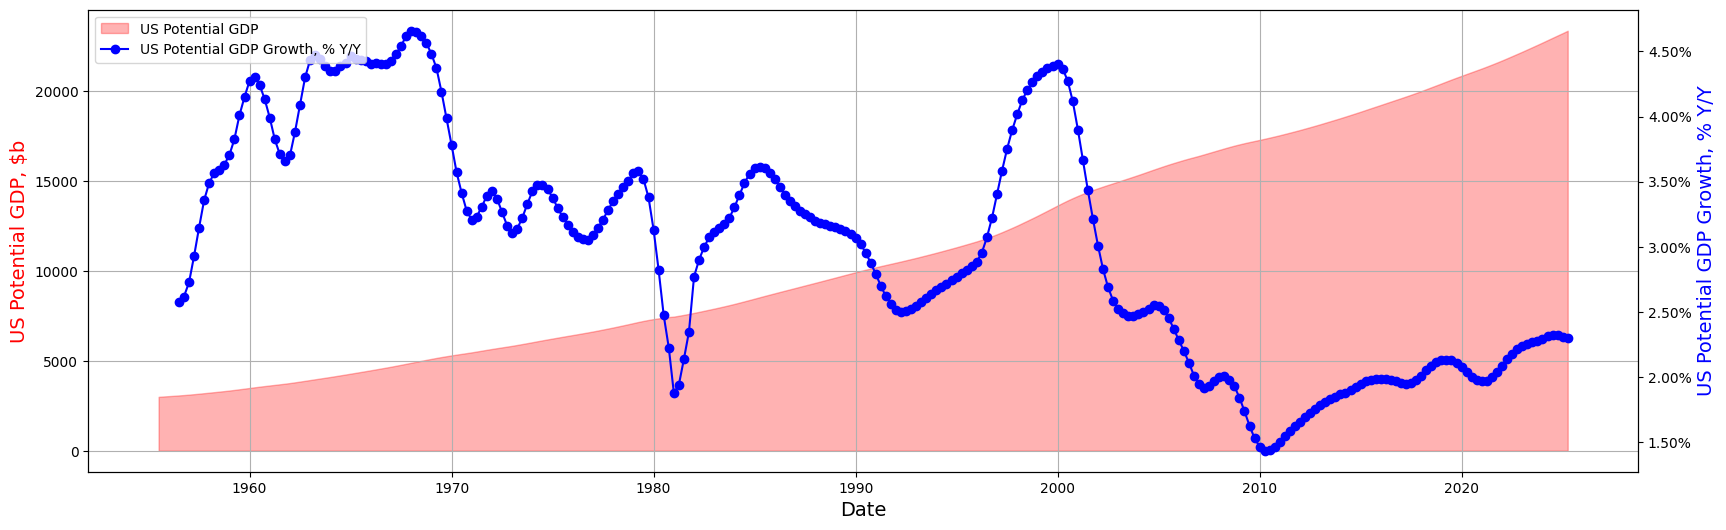

In [8]:
# Visuals GDPPOT
# https://cmdlinetips.com/2019/10/how-to-make-a-plot-with-two-different-y-axis-in-python-with-matplotlib/

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US potential GDP curve
ax.fill_between(gdppot.index, gdppot.GDPPOT, color="red", alpha=0.3, label="US Potential GDP")

# Creating a secondary y-axis for GDP growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(gdppot.gdppot_us_yoy, color="blue", marker="o", label="US Potential GDP Growth, % Y/Y")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("US Potential GDP, $b", color="red", fontsize=14)
ax2.set_ylabel("US Potential GDP Growth, % Y/Y", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## 1.2) Inflation - CPI Core

Here's a breakdown of inflation:

**What is inflation?**

Inflation is the rate at which the general level of prices for goods and services is rising, and consequently, the purchasing power of currency is falling. It's typically expressed as a percentage change.

**How many types of inflation are there?**

Inflation is often categorized into several types based on its cause and rate:

* **Demand-Pull Inflation:** Occurs when there is strong aggregate demand in the economy that outpaces the supply of goods and services. Too much money chasing too few goods.
* **Cost-Push Inflation:** Occurs when the general price level increases due to rising costs of production, such as wages, raw materials, or energy.
* **Built-In Inflation (Wage-Price Inflation):** Occurs when workers demand higher wages to keep up with rising prices, leading to a wage-price spiral.
* **Creeping Inflation (Mild Inflation):** A slow and gradual rise in prices, typically a single-digit percentage per year.
* **Walking Inflation:** Inflation rising at a moderate rate, typically in the range of 3-10% per year. It can start to cause economic concern.
* **Galloping Inflation (Runaway Inflation):** A rapid and uncontrolled inflation where prices rise at double-digit or even higher rates each year.
* **Hyperinflation:** An extreme and rapid form of inflation where prices rise dramatically in a very short period, often at triple-digit or higher rates per year. This can lead to the breakdown of an economy.
* **Stagflation:** A unique condition characterized by slow economic growth, high unemployment, and simultaneously high inflation.
* **Deflation:** The opposite of inflation, where there is a persistent fall in the general level of prices.

**How is it calculated? Give its formula?**

In India, the primary measure of inflation for monetary policy purposes is based on the **Consumer Price Index (CPI)**. The inflation rate for a specific period is calculated as the percentage change in the CPI over that time.

The formula for calculating the inflation rate is:

**Inflation Rate = ((CPI in Current Period – CPI in Previous Period) / CPI in Previous Period) × 100**

For example, to calculate the annual inflation rate for the year 2025, you would use the CPI for a specific month in 2025 and the CPI for the same month in 2024.

**Who calculates inflation of India?**

The **National Statistical Office (NSO)**, under the **Ministry of Statistics and Programme Implementation (MOSPI)**, collects the data and calculates the Consumer Price Index (CPI) in India. The **Reserve Bank of India (RBI)** then uses the CPI as a key benchmark for monitoring price stability, targeting inflation, and guiding its monetary policy decisions.
You can explore more details [here](https://www.investopedia.com/terms/i/inflation.asp) and [here](https://vajiramandravi.com/upsc-exam/inflation/). Would you like to see **historical inflation trends** or how different countries manage inflation? 🚀

In [10]:
# # "Core CPI index", MONTHLY
# https://fred.stlouisfed.org/series/CPILFESL
# The "Consumer Price Index for All Urban Consumers: All Items Less Food & Energy"
# is an aggregate of prices paid by urban consumers for a typical basket of goods, excluding food and energy.
# This measurement, known as "Core CPI," is widely used by economists because food and energy have very volatile prices.
cpilfesl = pdr.DataReader("CPILFESL", "fred", start=start)

In [11]:
cpilfesl['cpi_core_yoy'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(12)-1
cpilfesl['cpi_core_mom'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(1)-1

cpilfesl.tail(13)

,CPILFESL,cpi_core_yoy,cpi_core_mom
DATE,,,
2024-04-01,317.596,0.036236,0.002633
2024-05-01,318.053,0.033905,0.001439
2024-06-01,318.343,0.032606,0.000912
2024-07-01,318.933,0.032283,0.001853
2024-08-01,319.839,0.032918,0.002841
2024-09-01,320.835,0.032899,0.003114
2024-10-01,321.688,0.032928,0.002659
2024-11-01,322.619,0.032801,0.002894
2024-12-01,323.296,0.032136,0.002098


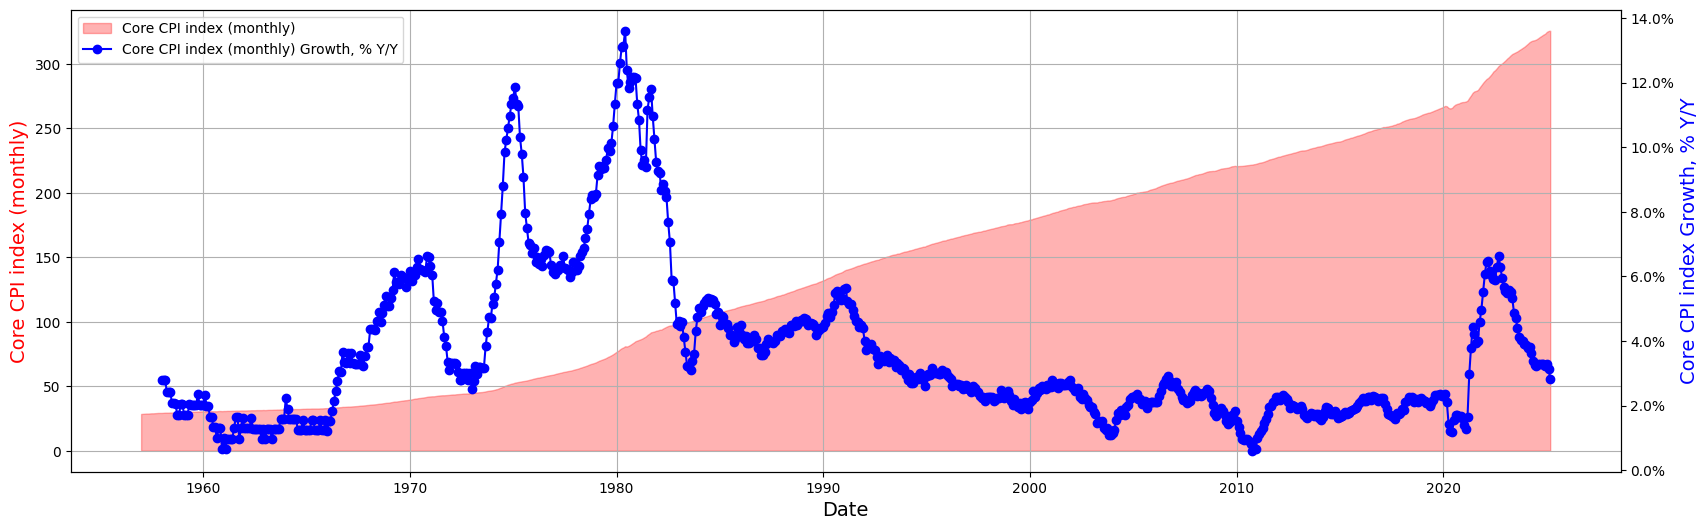

In [ ]:
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under CPI
ax.fill_between(cpilfesl.index, cpilfesl.CPILFESL, color="red", alpha=0.3, label="Core CPI index (monthly)")

# Creating a secondary y-axis for CPI growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(cpilfesl.cpi_core_yoy, color="blue", marker="o", label="Core CPI index (monthly) Growth, % Y/Y")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Core CPI index (monthly)", color="red", fontsize=14)
ax2.set_ylabel("Core CPI index Growth, % Y/Y", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## 1.3 Interest rates

In [12]:
# Fed rate https://fred.stlouisfed.org/series/FEDFUNDS
fedfunds = pdr.DataReader("FEDFUNDS", "fred", start=start)
fedfunds.tail(10)

,FEDFUNDS
DATE,
2024-08-01,5.33
2024-09-01,5.13
2024-10-01,4.83
2024-11-01,4.64
2024-12-01,4.48
2025-01-01,4.33
2025-02-01,4.33
2025-03-01,4.33
2025-04-01,4.33


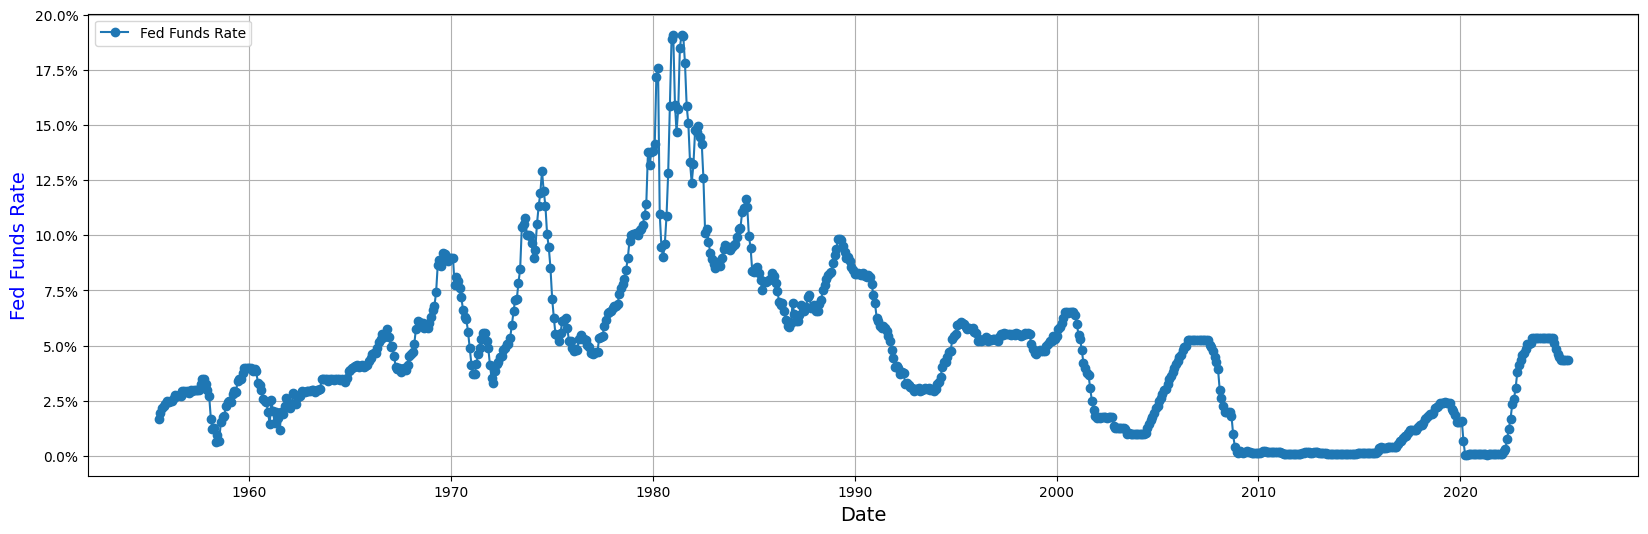

In [13]:
# Fed Funds
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US potential GDP curve
# ax.fill_between(fedfunds.index, fedfunds.FEDFUNDS, color="red", alpha=0.3, label="Core CPI index (monthly)")

# # Creating a secondary y-axis for GDP growth percentage
# ax2 = ax.twinx()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.plot(fedfunds.index, fedfunds.FEDFUNDS/100, marker="o", label="Fed Funds Rate")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Fed Funds Rate", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

plt.show()

In [14]:
# https://fred.stlouisfed.org/series/DGS1
dgs1 = pdr.DataReader("DGS1", "fred", start=start)
dgs1.tail()

,DGS1
DATE,
2025-05-28,4.16
2025-05-29,4.13
2025-05-30,4.11
2025-06-02,4.12
2025-06-03,4.12


Other rates for US Treasury: https://fred.stlouisfed.org/categories/115  
* https://fred.stlouisfed.org/series/DGS2
* https://fred.stlouisfed.org/series/DGS3
* https://fred.stlouisfed.org/series/DGS5
* https://fred.stlouisfed.org/series/DGS10
...

In [15]:
# https://fred.stlouisfed.org/series/DGS5
dgs5 = pdr.DataReader("DGS5", "fred", start=start)
dgs5.tail()

,DGS5
DATE,
2025-05-28,4.05
2025-05-29,4.00
2025-05-30,3.96
2025-06-02,4.01
2025-06-03,4.04


## 1.4 SNP500

In [16]:
# Other indexes: https://stooq.com/t/

# SPX= S&P500
spx_index = pdr.get_data_stooq('^SPX', start, end)
spx_index.head()

,Open,High,Low,Close,Volume
Date,,,,,
2025-06-03,5938.56,5981.35,5929.00,5970.37,2.995304e+09
2025-06-02,5896.68,5937.40,5861.43,5935.94,2.765358e+09
2025-05-30,5903.67,5922.14,5843.66,5911.69,4.815798e+09
2025-05-29,5939.96,5943.13,5873.80,5912.17,2.860741e+09
2025-05-28,5925.54,5939.92,5881.88,5888.55,2.671436e+09


In [17]:
# 252 trading days a year
  # REVERSE ORDER OF THE DATA!!!
spx_index['spx_dod'] = (spx_index.Close/spx_index.Close.shift(-1)-1)
spx_index['spx_qoq'] = (spx_index.Close/spx_index.Close.shift(-63)-1)
spx_index['spx_yoy'] = (spx_index.Close/spx_index.Close.shift(-252)-1)

In [18]:
spx_index.head()

,Open,High,Low,Close,Volume,spx_dod,spx_qoq,spx_yoy
Date,,,,,,,,
2025-06-03,5938.56,5981.35,5929.00,5970.37,2.995304e+09,0.005800,0.033267,0.140367
2025-06-02,5896.68,5937.40,5861.43,5935.94,2.765358e+09,0.004102,0.014739,0.127017
2025-05-30,5903.67,5922.14,5843.66,5911.69,4.815798e+09,-0.000081,-0.007190,0.114144
2025-05-29,5939.96,5943.13,5873.80,5912.17,2.860741e+09,0.004011,0.008632,0.114511
2025-05-28,5925.54,5939.92,5881.88,5888.55,2.671436e+09,-0.005571,-0.011335,0.117830


In [19]:
spx_truncated = spx_index[spx_index.index>='1990-01-01']

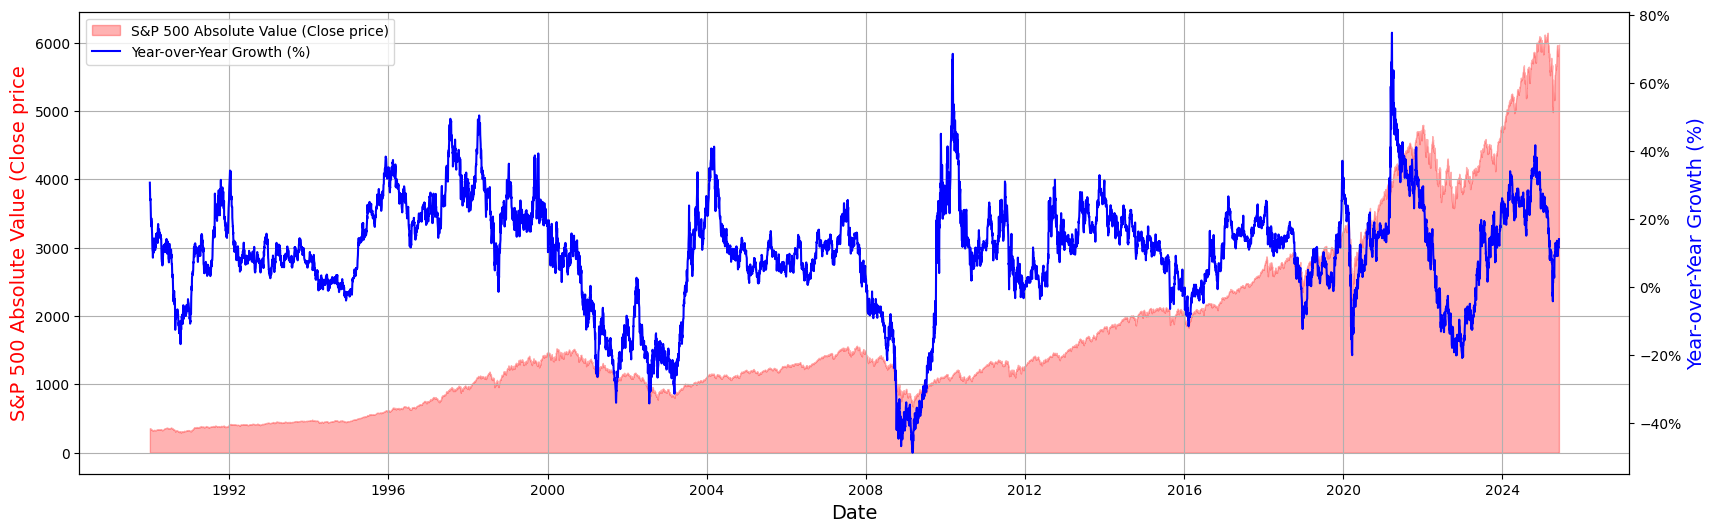

In [20]:
# S&P500 abs. vs. relative growth
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under CPI
ax.fill_between(spx_truncated.index, spx_truncated.Close, color="red", alpha=0.3, label="S&P 500 Absolute Value (Close price)")

# Creating a secondary y-axis for CPI growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(spx_truncated.spx_yoy,
         color="blue",
        #  marker=".",
         label="Year-over-Year Growth (%)")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("S&P 500 Absolute Value (Close price", color="red", fontsize=14)
ax2.set_ylabel("Year-over-Year Growth (%)", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

# 2) Data Sources for Stocks

## 2.1 OHLCV data daily - INDEXES

In [21]:
# INDEXES from Yahoo Finance
# DAX index (XETRA - XETRA Delayed Price. Currency in EUR)
# WEB: https://finance.yahoo.com/quote/%5EGDAXI
# Option 1: dax_daily = yf.download(tickers = ["^GDAXI"],
#                      period = "max",
#                      interval = "1d")

# Option 2 (preferred):
# Download data with Adj Close for more accurate price reflections
ticker_obj = yf.Ticker("^GDAXI")
dax_daily = ticker_obj.history(start = start)

In [22]:
dax_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-05-29 00:00:00+02:00,24255.009766,24255.009766,23917.060547,23933.230469,42765200,0.0,0.0
2025-05-30 00:00:00+02:00,23963.490234,24181.529297,23958.429688,23997.480469,110527000,0.0,0.0
2025-06-02 00:00:00+02:00,23865.380859,23993.220703,23740.089844,23930.669922,53147300,0.0,0.0
2025-06-03 00:00:00+02:00,24031.960938,24101.550781,23826.390625,24091.619141,50506800,0.0,0.0
2025-06-04 00:00:00+02:00,24253.689453,24346.150391,24137.689453,24276.480469,0,0.0,0.0


In [23]:
# normally 252 trading days
dax_daily['adj_close_last_year'] = dax_daily['Close'].shift(252)
dax_daily['yoy_growth'] = dax_daily['Close'] / dax_daily['adj_close_last_year'] -1

In [24]:
dax_daily

,Open,High,Low,Close,Volume,Dividends,Stock Splits,adj_close_last_year,yoy_growth
Date,,,,,,,,,
1987-12-30 00:00:00+01:00,1005.190002,1005.190002,1005.190002,1005.190002,0,0.0,0.0,NaN,NaN
1988-01-04 00:00:00+01:00,956.489990,956.489990,956.489990,956.489990,0,0.0,0.0,NaN,NaN
1988-01-05 00:00:00+01:00,996.099976,996.099976,996.099976,996.099976,0,0.0,0.0,NaN,NaN
1988-01-06 00:00:00+01:00,1006.010010,1006.010010,1006.010010,1006.010010,0,0.0,0.0,NaN,NaN
1988-01-07 00:00:00+01:00,1014.469971,1014.469971,1014.469971,1014.469971,0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2025-05-29 00:00:00+02:00,24255.009766,24255.009766,23917.060547,23933.230469,42765200,0.0,0.0,18496.789062,0.293913
2025-05-30 00:00:00+02:00,23963.490234,24181.529297,23958.429688,23997.480469,110527000,0.0,0.0,18497.939453,0.297306
2025-06-02 00:00:00+02:00,23865.380859,23993.220703,23740.089844,23930.669922,53147300,0.0,0.0,18608.160156,0.286031


<Axes: xlabel='Date'>

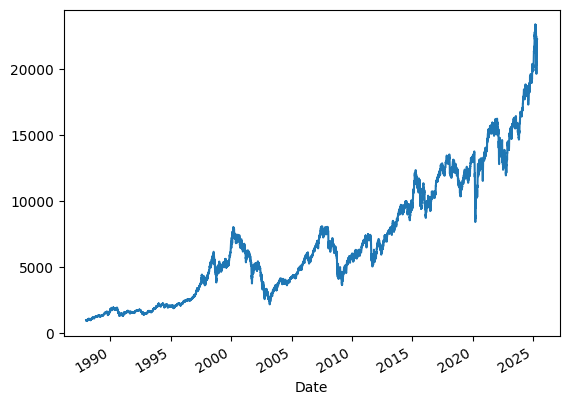

In [ ]:
dax_daily['Close'].plot.line()

In [ ]:
# delayed 15 min : https://finance.yahoo.com/quote/%5ESPX/
# S&P 500 INDEX : Chicago Options - Chicago Options Delayed Price. Currency in USD
ticker_obj = yf.Ticker("^SPX")
snp500_daily = ticker_obj.history(start = start, interval = "1d")

# old version:
# snp500_daily = yf.download(tickers = "^SPX",
#                      period = "max",
#                      interval = "1d")

In [ ]:
snp500_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-04-22 00:00:00-04:00,5207.669922,5309.609863,5207.669922,5287.759766,4666950000,0.0,0.0
2025-04-23 00:00:00-04:00,5395.919922,5469.689941,5356.169922,5375.859863,5371390000,0.0,0.0
2025-04-24 00:00:00-04:00,5381.379883,5489.399902,5371.959961,5484.770020,4697710000,0.0,0.0
2025-04-25 00:00:00-04:00,5489.729980,5528.109863,5455.859863,5525.209961,4236580000,0.0,0.0
2025-04-28 00:00:00-04:00,5529.220215,5553.660156,5468.640137,5528.750000,2748913513,0.0,0.0


In [ ]:
# https://finance.yahoo.com/quote/%5EGSPC/
# SNP - SNP Real Time Price. Currency in USD
# https://www.investopedia.com/insights/introduction-to-stock-market-indices/

ticker_obj = yf.Ticker("^GSPC")
snp500_daily_non_delayed = ticker_obj.history(start = start, interval = "1d")

# old version:
# snp500_daily_non_delayed = yf.download(tickers = "^GSPC",
#                      period = "max",
#                      interval = "1d")

In [ ]:
snp500_daily_non_delayed.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-04-22 00:00:00-04:00,5207.669922,5309.609863,5207.669922,5287.759766,4666950000,0.0,0.0
2025-04-23 00:00:00-04:00,5395.919922,5469.689941,5356.169922,5375.859863,5371390000,0.0,0.0
2025-04-24 00:00:00-04:00,5381.379883,5489.399902,5371.959961,5484.770020,4697710000,0.0,0.0
2025-04-25 00:00:00-04:00,5489.729980,5528.109863,5455.859863,5525.209961,4236580000,0.0,0.0
2025-04-28 00:00:00-04:00,5529.220215,5553.660156,5468.640137,5528.750000,2754594000,0.0,0.0


In [ ]:
# Dow Jones Industrial Average: https://finance.yahoo.com/quote/%5EDJI?.tsrc=fin-srch

ticker_obj = yf.Ticker("^DJI")
dji_daily = ticker_obj.history(start = start, interval = "1d")

# dji_daily = yf.download(tickers = "^DJI",
#                      period = "max",
#                      interval = "1d")

## 2.2 OHLCV data daily - ETFs

In [ ]:
# https://finance.yahoo.com/quote/VOO?.tsrc=fin-srch

ticker_obj = yf.Ticker("VOO")
voo_etf = ticker_obj.history(start = start, interval = "1d")

# voo_etf = yf.download(tickers = "VOO",
#                      period = "max",
#                      interval = "1d")


In [ ]:
voo_etf.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2025-04-22 00:00:00-04:00,478.070007,486.480011,477.190002,484.290009,6236300,0.0,0.0,0.0
2025-04-23 00:00:00-04:00,496.690002,501.179993,490.700012,492.070007,8047600,0.0,0.0,0.0
2025-04-24 00:00:00-04:00,493.260010,503.000000,492.220001,502.410004,6184300,0.0,0.0,0.0
2025-04-25 00:00:00-04:00,502.440002,506.519989,499.750000,506.109985,6926500,0.0,0.0,0.0
2025-04-28 00:00:00-04:00,506.809998,508.691803,501.000000,506.420013,4179047,0.0,0.0,0.0


In [ ]:
# ETFs
# WisdomTree India Earnings Fund (EPI)
# NYSEArca - Nasdaq Real Time Price. Currency in USD
# WEB: https://finance.yahoo.com/quote/EPI/history?p=EPI

ticker_obj = yf.Ticker("EPI")
epi_etf_daily = ticker_obj.history(start = start, interval = "1d")

# epi_etf_daily = yf.download(tickers = "EPI",
#                      period = "max",
#                      interval = "1d")

In [ ]:
epi_etf_daily.head()
print(epi_etf_daily.shape)

(4321, 8)


In [ ]:
# find dividends impact on Close vs. Adj.Close
epi_etf_daily[epi_etf_daily.Dividends>0].tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2021-12-27 00:00:00-05:00,33.577714,33.801816,33.577714,33.764465,379100,0.192,0.0,0.0
2022-03-25 00:00:00-04:00,33.563275,33.666313,33.432129,33.666313,584400,0.115,0.0,0.0
2022-06-24 00:00:00-04:00,29.420325,29.778746,29.370545,29.768789,387900,1.845,0.0,0.0
2023-06-26 00:00:00-04:00,34.020314,34.070182,33.960471,33.990395,634600,0.060,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0


In [ ]:
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [ ]:
# find dividends - diff for Close vs. Adj Close
# Open/Close for 06-25 diff is close to divs = 1.845 (~1.58 for Open and 1.3 for Close)
# HELP: https://help.yahoo.com/kb/SLN28256.html#:~:text=Adjusted%20close%20is%20the%20closing,Security%20Prices%20(CRSP)%20standards.
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [ ]:
# Previous option : no Div. dates , same stats
epi_etf_daily2 = yf.download(tickers = "EPI",
                     period = "max",
                     interval = "1d")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [ ]:
epi_etf_daily2[epi_etf_daily2.index>='2024-12-23'].head()

Price,Close,High,Low,Open,Volume
Ticker,EPI,EPI,EPI,EPI,EPI
Date,,,,,
2024-12-23,45.869080,45.879052,45.609761,45.609761,630400
2024-12-24,45.899002,45.928922,45.709503,45.719475,277100
2024-12-26,45.820000,45.840000,45.700001,45.840000,685600
2024-12-27,45.639999,45.650002,45.500000,45.570000,774900
2024-12-30,45.090000,45.180000,44.980000,45.180000,1442100


<Axes: title={'center': "EPI's etf stock price"}, xlabel='Date'>

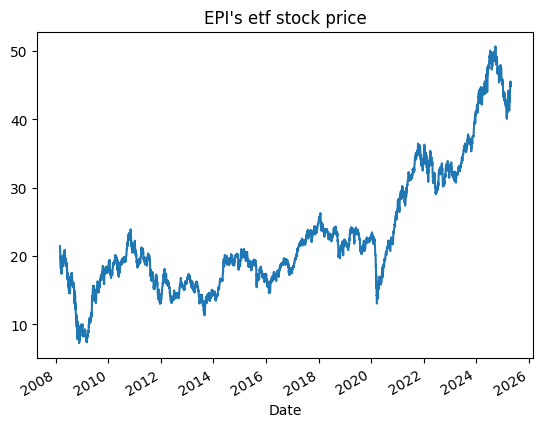

In [ ]:
# About yFinance: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html

epi_etf_daily['Close'].plot(title="EPI's etf stock price")

In [ ]:
# get actions, incl. dividends - as a dataFrame
epi = yf.Ticker('EPI')
epi.get_actions()

,Dividends,Stock Splits,Capital Gains
Date,,,
2008-12-22 00:00:00-05:00,0.091,0.0,0.0
2009-03-23 00:00:00-04:00,0.007,0.0,0.0
2009-06-22 00:00:00-04:00,0.002,0.0,0.0
2009-09-21 00:00:00-04:00,0.045,0.0,0.0
2009-12-21 00:00:00-05:00,0.006,0.0,0.0
2010-06-28 00:00:00-04:00,0.065,0.0,0.0
2010-09-20 00:00:00-04:00,0.065,0.0,0.0
2010-12-22 00:00:00-05:00,0.013,0.0,0.0
2011-06-22 00:00:00-04:00,0.062,0.0,0.0


In [ ]:
# get dividends as Series
epi.get_dividends()

,Dividends
Date,
2008-12-22 00:00:00-05:00,0.091
2009-03-23 00:00:00-04:00,0.007
2009-06-22 00:00:00-04:00,0.002
2009-09-21 00:00:00-04:00,0.045
2009-12-21 00:00:00-05:00,0.006
2010-06-28 00:00:00-04:00,0.065
2010-09-20 00:00:00-04:00,0.065
2010-12-22 00:00:00-05:00,0.013
2011-06-22 00:00:00-04:00,0.062


In [ ]:
# India's stock example
# https://www.nseindia.com/market-data/live-equity-market
EICHERMOT = yf.download(tickers = "EICHERMOT.NS",
                     period = "max",
                     interval = "1d")

[*********************100%***********************]  1 of 1 completed


In [ ]:
EICHERMOT

Price,Close,High,Low,Open,Volume
Ticker,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS
Date,,,,,
1996-01-01,1.145841,1.145841,1.145841,1.145841,22000
1996-01-02,1.149023,1.158572,1.145840,1.145840,31000
1996-01-03,1.161755,1.161755,1.161755,1.161755,11000
1996-01-04,1.161755,1.161755,1.145840,1.145840,16000
1996-01-05,1.145841,1.161755,1.126743,1.161755,6000
...,...,...,...,...,...
2025-04-22,5784.000000,5906.500000,5766.500000,5811.000000,459537
2025-04-23,5740.000000,5816.500000,5605.500000,5789.000000,582611


## 2.3 Paid data - Poligon.io (news endpoint) and Alpha Vantage

In [ ]:
# [Polygon.io] Please read the article (section "Polygon.io News API"): https://pythoninvest.com/long-read/chatgpt-api-for-financial-news-summarization
# Endpoint: https://polygon.io/docs/stocks/get_v2_reference_news

In [ ]:
# [Alpha Vantage] Please read the article (section "Data Sources"): https://pythoninvest.com/long-read/stock-screening-using-paid-data
# Endpoint: https://www.alphavantage.co/documentation/#fundamentals

## 2.4 Macroeconomics

* some indicator examples: gold reserves vs. volatility

In [ ]:
# Gold reserves excl. gold for China
# https://fred.stlouisfed.org/series/TRESEGCNM052N

In [ ]:
gold_reserves = pdr.DataReader("TRESEGCNM052N", "fred", start=start)

<Axes: xlabel='DATE'>

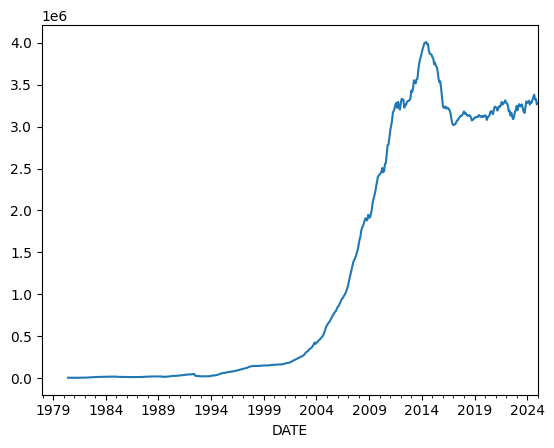

In [ ]:
gold_reserves.TRESEGCNM052N.plot.line()

In [ ]:
#  CBOE Gold ETF Volatility Index (GVZCLS)
# https://fred.stlouisfed.org/series/GVZCLS
gold_volatility = pdr.DataReader("GVZCLS", "fred", start=start)

<Axes: xlabel='DATE'>

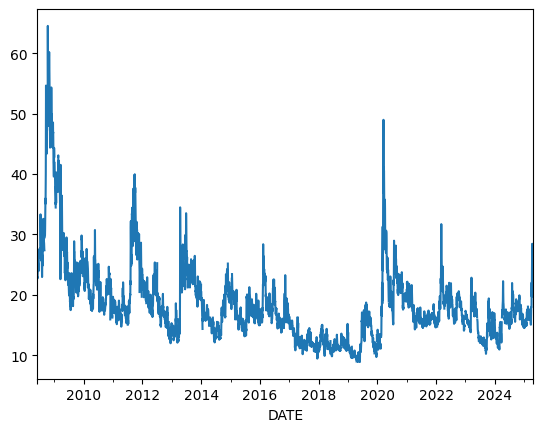

In [ ]:
gold_volatility.GVZCLS.plot.line()

In [ ]:
#  Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma (DCOILWTICO)
# https://fred.stlouisfed.org/series/DCOILWTICO
oil_wti = pdr.DataReader("DCOILWTICO", "fred", start=start)

<Axes: xlabel='DATE'>

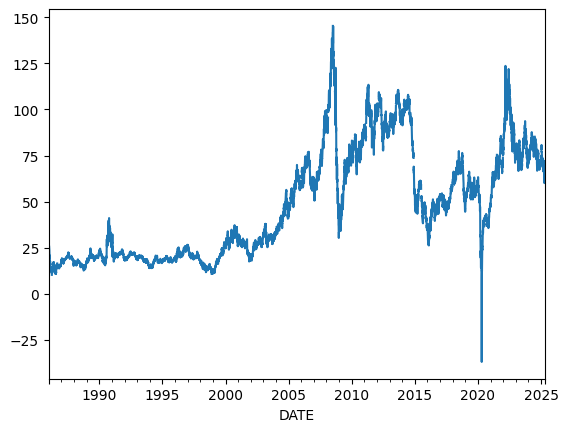

In [ ]:
# there is a bug in the data? negative price?
oil_wti.DCOILWTICO.plot.line()

In [ ]:
# Crude Oil Prices: Brent - Europe (DCOILBRENTEU)
# https://fred.stlouisfed.org/series/DCOILBRENTEU
oil_brent = pdr.DataReader("DCOILBRENTEU", "fred", start=start)

<Axes: xlabel='DATE'>

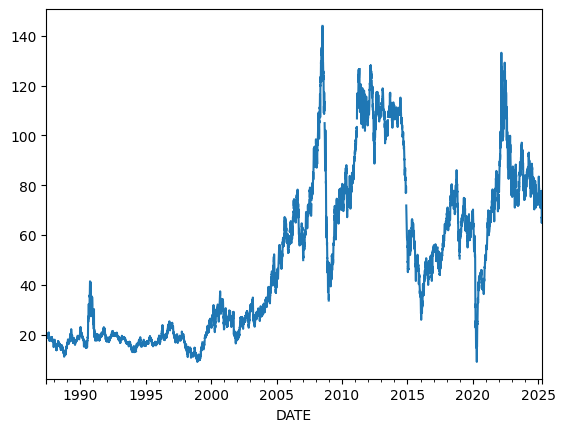

In [ ]:
oil_brent.DCOILBRENTEU.plot.line()

In [ ]:
# Web Scraping for Macro
# can't call directly via pd.read_html() as it returns 403 (forbidden) --> need to do a bit of work, but still no Selenium
# https://tradingeconomics.com/united-states/indicators
import requests
from bs4 import BeautifulSoup


url = "https://tradingeconomics.com/united-states/indicators"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

response = requests.get(url, headers=headers)

In [ ]:

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # You need to be able to find this table tag and read all behind it
    # Find the div with class "table-responsive"
    table_div = soup.find("div", class_="table-responsive")

    # Extract the table within the div
    table = table_div.find("table")

    # Use pandas to read the table into a DataFrame
    df = pd.read_html(str(table))[0]  # Assuming there's only one table, otherwise, loop through the list

    # Display the DataFrame
    print(df)
else:
    print("Failed to retrieve data from the webpage.")

                  Unnamed: 0     Last  Previous  Highest    Lowest  \
0                   Currency    98.93     99.71   165.00     70.70   
1               Stock Market  5521.00   5525.00  6153.00      4.40   
2            GDP Growth Rate     2.40      3.10    35.20    -28.10   
3     GDP Annual Growth Rate     2.50      2.70    13.40     -7.50   
4          Unemployment Rate     4.20      4.10    14.90      2.50   
5          Non Farm Payrolls   228.00    117.00  4631.00 -20471.00   
6             Inflation Rate     2.40      2.80    23.70    -15.80   
7         Inflation Rate MoM    -0.10      0.20     2.00     -1.80   
8              Interest Rate     4.50      4.50    20.00      0.25   
9           Balance of Trade  -123.00   -131.00     1.95   -131.00   
10           Current Account  -304.00   -310.00     9.96   -310.00   
11    Current Account to GDP    -3.90     -3.30     0.20     -6.00   
12    Government Debt to GDP   122.00    122.00   126.00     31.80   
13         Governmen

<ipython-input-57-7e84ec23ab8e>:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]  # Assuming there's only one table, otherwise, loop through the list


In [ ]:
df

,Unnamed: 0,Last,Previous,Highest,Lowest,Unnamed: 5,Unnamed: 6
0,Currency,98.93,99.71,165.00,70.70,NaN,Apr/25
1,Stock Market,5521.00,5525.00,6153.00,4.40,points,Apr/25
2,GDP Growth Rate,2.40,3.10,35.20,-28.10,percent,Dec/24
3,GDP Annual Growth Rate,2.50,2.70,13.40,-7.50,percent,Dec/24
4,Unemployment Rate,4.20,4.10,14.90,2.50,percent,Mar/25
5,Non Farm Payrolls,228.00,117.00,4631.00,-20471.00,Thousand,Mar/25
6,Inflation Rate,2.40,2.80,23.70,-15.80,percent,Mar/25
7,Inflation Rate MoM,-0.10,0.20,2.00,-1.80,percent,Mar/25
8,Interest Rate,4.50,4.50,20.00,0.25,percent,Mar/25
9,Balance of Trade,-123.00,-131.00,1.95,-131.00,USD Billion,Feb/25


## 2.5) Financial reporting - EDGAR (in Yahoo)

In [ ]:
# let's check for NVDA
nvda =  yf.Ticker('NVDA')

In [ ]:
# yearly financials for the last 4 years
nvda.financials


,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Tax Effect Of Unusual Items,0.0,0.0,-284130000.0,0.0
Tax Rate For Calcs,0.133,0.12,0.21,0.019
Normalized EBITDA,86137000000.0,35583000000.0,7340000000.0,11351000000.0
Total Unusual Items,0.0,0.0,-1353000000.0,0.0
Total Unusual Items Excluding Goodwill,0.0,0.0,-1353000000.0,0.0
Net Income From Continuing Operation Net Minority Interest,72880000000.0,29760000000.0,4368000000.0,9752000000.0
Reconciled Depreciation,1864000000.0,1508000000.0,1544000000.0,1174000000.0
Reconciled Cost Of Revenue,32639000000.0,16621000000.0,11618000000.0,9439000000.0
EBITDA,86137000000.0,35583000000.0,5987000000.0,11351000000.0
EBIT,84273000000.0,34075000000.0,4443000000.0,10177000000.0


In [ ]:
# balance sheet
nvda.balance_sheet

,2025-01-31,2024-01-31,2023-01-31,2022-01-31,2021-01-31
Treasury Shares Number,NaN,NaN,NaN,NaN,13800000000.0
Ordinary Shares Number,24477000000.0,24640000000.0,24661365720.0,25060000000.0,NaN
Share Issued,24477000000.0,24640000000.0,24661365720.0,25060000000.0,NaN
Net Debt,NaN,2429000000.0,7564000000.0,8956000000.0,6116000000.0
Total Debt,10270000000.0,11056000000.0,12031000000.0,11831000000.0,NaN
...,...,...,...,...,...
Allowance For Doubtful Accounts Receivable,NaN,NaN,NaN,NaN,-21000000.0
Gross Accounts Receivable,NaN,NaN,NaN,NaN,2450000000.0
Cash Cash Equivalents And Short Term Investments,43210000000.0,25984000000.0,13296000000.0,21208000000.0,NaN
Other Short Term Investments,34621000000.0,18704000000.0,9907000000.0,19218000000.0,NaN


In [ ]:
# Basic info:
nvda.basic_info

/usr/local/lib/python3.11/dist-packages/yfinance/base.py:302: DeprecationWarning: 'Ticker.basic_info' is deprecated and will be removed in future, Switch to 'Ticker.fast_info'
  warnings.warn("'Ticker.basic_info' is deprecated and will be removed in future, Switch to 'Ticker.fast_info'", DeprecationWarning)


lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [ ]:
# marketCap is quite useful, but don't know when it was updated? Daily?
nvda.basic_info['marketCap']/1e9

2653.011970569656

In [ ]:
# read this article for full info: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html

## 2.6 Web Scraping - company info for clustering

In [ ]:
# ask chatGPT: emulate clicking the link and downloading the content
import requests
from bs4 import BeautifulSoup

# URL of the webpage
url = "https://companiesmarketcap.com/"

# Define headers with a user-agent to mimic a web browser
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

# Send a GET request to the URL with headers
response = requests.get(url, headers=headers)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # Find the download link within the webpage
    download_link = soup.find("a", {"rel": "nofollow", "href": "?download=csv"})

    # If the download link is found
    if download_link:
        # Extract the href attribute which contains the actual download link
        download_url = 'https://companiesmarketcap.com/'+download_link["href"]

        # Download the CSV file using the obtained download URL
        download_response = requests.get(download_url, headers=headers)

        # Check if the download request was successful
        if download_response.status_code == 200:
            # Save the content of the response to a local file
            with open("global_stocks.csv", "wb") as f:
                f.write(download_response.content)
            print("CSV file downloaded successfully.")
        else:
            print("Failed to download the CSV file.")
    else:
        print("Download link not found on the webpage.")
else:
    print("Failed to retrieve data from the webpage.")

CSV file downloaded successfully.


In [ ]:
global_stocks = pd.read_csv("/content/global_stocks.csv")

In [ ]:
global_stocks['marketcap_b_usd'] = global_stocks.marketcap/1e9

In [ ]:
global_stocks.head(10)

,Rank,Name,Symbol,marketcap,price (USD),country,marketcap_b_usd
0,1,Apple,AAPL,3156744077312,210.14000,United States,3156.744077
1,2,Microsoft,MSFT,2907875573760,391.16000,United States,2907.875574
2,3,NVIDIA,NVDA,2653012099072,108.73000,United States,2653.012099
3,4,Amazon,AMZN,1991947452416,187.70000,United States,1991.947452
4,5,Alphabet (Google),GOOG,1936614883328,162.42000,United States,1936.614883
5,6,Saudi Aramco,2222.SR,1661535281558,6.86996,Saudi Arabia,1661.535282
6,7,Meta Platforms (Facebook),META,1351986577408,549.74000,United States,1351.986577
7,8,Berkshire Hathaway,BRK-B,1146708295680,530.94000,United States,1146.708296
8,9,Tesla,TSLA,920808062976,285.88000,United States,920.808063
9,10,Broadcom,AVGO,904984330240,192.47000,United States,904.984330


In [ ]:
global_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             10000 non-null  int64  
 1   Name             10000 non-null  object 
 2   Symbol           9999 non-null   object 
 3   marketcap        10000 non-null  int64  
 4   price (USD)      10000 non-null  float64
 5   country          10000 non-null  object 
 6   marketcap_b_usd  10000 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 547.0+ KB
